# Window Functions for QPE

In quantum phase estimation (QPE), we aim to estimate the eigenvalue of a unitary using finite quantum resources. This means that: 

1) We use a finite number $m$ of phase qubits in the algorithm. In other words, phase register dimension is $2^m$.
2) We take discrete samples in time evolutions (in units of $2\pi$). 

These factors can distort the signal, or the output probability distribution of measurement outcomes of QPE. 

In QPE formulation, we first apply a window function to the phase register. In the textbook ("vanilla") version of QPE, this function, called the "rectangular" window, is implemented as Hadamard gates applied to each phase qubit. This is the default for QPE, but it can be set explicitly in the same way as the other window functions by using the [`RectWindow`](https://construct.psiquantum.com/docs/psiqdk-algorithms/autoapi/psiqdk/algorithms/subroutines/qpe_window_functions.html#psiqdk.algorithms.subroutines.qpe_window_functions.RectWindow) `Qubrick`. In general, the window distribution is multiplied with samples of the Hamiltonian simulation to output a final distribution of outcomes.

Depending on the form of the window function, one can greatly reduce the impact of the signal distortion. In this tutorial, we go through the cosine window function, introduced in "Effects of Cosine Tapering Window on Quantum Phase Estimation" ([arXiv:2110.09590](https://arxiv.org/abs/2110.09590)) and Kaiser window function, introduced in "Analyzing Prospects for Quantum Advantage in Topological Data Analysis" ([arXiv:2209.13581](https://arxiv.org/abs/2209.13581)), and show how they can improve the quality of the output signal of QPE in hard problem instances. In algorithmic terms, this is related to boosting the success probability of QPE, which becomes important when we need to apply QPE coherently.

In [1]:
from psiqdk.workbench import QPU, QUFixed, Qubits, Qubrick
from psiqdk.algorithms import CosineWindow, QPE, RectWindow, WindowStatePrep
from psiqdk.algorithms.utils.window_utils import compute_amplitudes_kaiser_window

import numpy as np
import matplotlib.pyplot as plt

We will use a simple phase gate as the unitary input to the QPE algorithm, same as in other QPE tutorials.

In [2]:
class SimplePhaseUnitary(Qubrick):
    """A Qubrick wrapper for the phase gate for debugging QPE routines.

    Allows for exact eigenphases to be implemented in QPE.
    """

    def __init__(self, phase: float, **kwargs):
        """Initialize the Qubrick.

        Args:
            phase: Phase, as a fraction of 2π.
        """
        self.phase = phase
        super().__init__(**kwargs)

    def _compute(self, psi: Qubits, ctrl: Qubits | int = 0):
        """Apply the Rz gate.

        Args:
            psi: State register for the computation.
            ctrl: Register to control the unitary on. Defaults to ``0``.
        """
        theta = 360 * self.phase
        psi.phase(theta, cond=ctrl)

## Cosine window

In the following example, we will simulate the vanilla QPE using rectangular and cosine window functions and plot the output probabilities of all possible measurement outcomes. 

> We use plain `Qubits` for representing the eigenstate and `QUFixed` (unsigned quantum fixed-point numbers) for the phase registers of QPE. You can find more information on setting up a QPE experiment in the [QPE tutorial](./Quantum_Phase_Estimation.ipynb). 

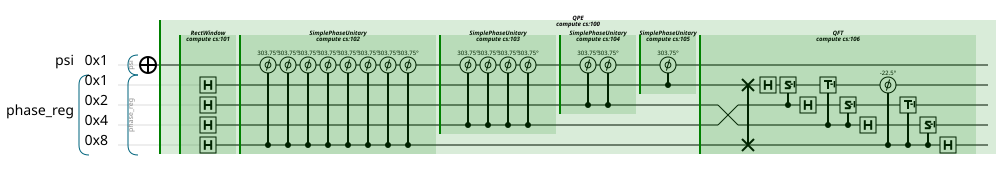

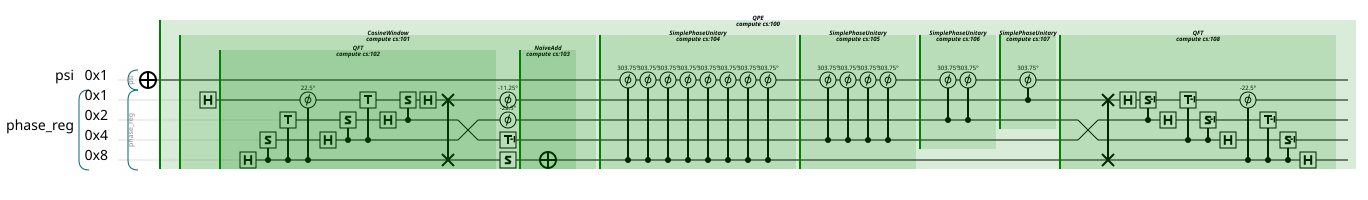

In [3]:
bits_of_precision = 4
phase = 1/2 + 1/4 + 1/16 + 1/32  # 0.84375

def run_qpe_with_window(window_qubrick, draw=False):
    qpu = QPU(num_qubits=bits_of_precision + 1)
    qpu.random_seed(1)
    psi = Qubits(1, "psi", qpu)    # the eigenstate register
    phase_reg = QUFixed(bits_of_precision, bits_of_precision, "phase_reg", qpu)

    # Initialize the Qubricks
    unitary = SimplePhaseUnitary(phase=phase)
    qpe = QPE(bits_of_precision=bits_of_precision, unitary=unitary, window_func=window_qubrick)

    # Prepare the eigenstate |1⟩ (hardcoded)
    psi.x()

    # Apply the QPE
    qpe.compute(psi, phase_reg)

    if draw:
        qpu.draw(show_qubricks=True)

    # Instead of sampling, peek at measurement probabilities
    probabilities = {
        ind / (1 << bits_of_precision): phase_reg.peek_read_probability(ind) 
        for ind in range(1 << bits_of_precision)
    }
    return probabilities

# Use rectangular window Qubrick
rect_window_prob = run_qpe_with_window(RectWindow(), True)
# Use cosine window Qubrick
cosine_window_prob = run_qpe_with_window(CosineWindow(), True)

Looking at the circuits, we can visually check how relatively inexpensive it is it apply the cosine window. The cosine window function requires applying QFT and some single-qubit gates, which, compared to the cost of doing the controlled unitary in QPE, is negligible.

Now let's compare the output signals or probability distributions using the two types of window functions.

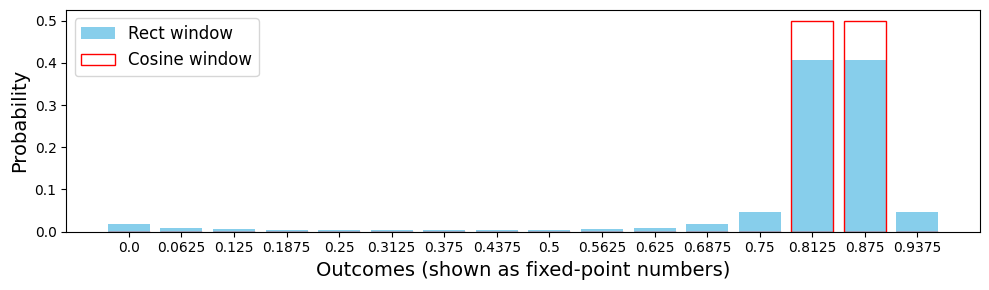

In [4]:
def plot_success_prob(keys, rect_window_prob, cosine_window_prob, kaiser_window_prob = None):
    plt.figure(figsize=(10, 3))
    plt.bar(
        x=range(len(keys)),
        color='skyblue',
        height=list(rect_window_prob),
        tick_label=list(keys),
        label='Rect window'
        )

    plt.bar(
        x=range(len(keys)),
        fill=False,
        edgecolor='red',
        height=list(cosine_window_prob),
        label='Cosine window'
        )
    
    if kaiser_window_prob is not None:
        plt.bar(
            x=range(len(keys)),
            fill=False,
            edgecolor='blue',
            height=list(kaiser_window_prob),
            label='Kaiser window'
            )

    plt.xlabel('Outcomes (shown as fixed-point numbers)', fontsize=14)
    plt.ylabel('Probability', fontsize=14)

    plt.legend(fontsize=12)
    plt.tight_layout()

plot_success_prob(rect_window_prob.keys(), rect_window_prob.values(), cosine_window_prob.values())

Recall that the true phase is $0.84375$, which is exactly halfway between two measurement outcomes, $0.8125$ and $0.875$. Using the textbook QPE (or the rectangular window function), we observe leakages in the output signal to outcomes far away from the true phase. On the other hand, using the cosine window, there is no visible leakage! 

To estimate the success probability of QPE, we can add up the probabilities of the two measurement outcomes or histogram bins closest to the true phase:

In [5]:
succ_prob_rect = np.sum(rect_window_prob[0.8125] + rect_window_prob[0.875])
succ_prob_cos = np.sum(cosine_window_prob[0.8125] + cosine_window_prob[0.875])

print(f"Success probability (rectangular window): {succ_prob_rect}")
print(f"Success probability (cosine window)     : {succ_prob_cos}")

assert np.isclose(succ_prob_rect, 8 / np.pi ** 2, 0.01)
assert np.isclose(succ_prob_cos, 1, 0.01)

Success probability (rectangular window): 0.8131786634360725
Success probability (cosine window)     : 0.9999999999999976


You can see that the success probability of QPE with rectangular window matches the one we explored in [Iterative QPE tutorial](./Iterative_QPE.ipynb), $8/\pi^2$ (the lower bound of QPE success probability, since we're looking at the worst case scenario, when the true phase is exactly halfway between two exactly representable outcomes). However, using the cosine window boosted the success probability to nearly $100\%$!

In other cases, when the true phase requires many more bits, one can also combine use of the window function with the standard trick of using extra bits and then discarding the additional bits to round to the nearest $n$ bits.

## Kaiser window

Now, there is a catch with the cosine window function. While it is very good at boosting the success probability of QPE for a hard problem instance, in which the true phase sits right in between two exactly representable values, it is surprisingly bad at maintaining a high success probability when the true phase is exactly representable itself or very close to that. In such case, use of the rectangular window function yields a high success probability where cosine window function doesn't. 

In practice, we don't know where the true phase lies and how close to exactly representable it is. Is there a window function that is "the best of both worlds"?

The answer is yes! Enter the Kaiser window, introduced in "Analyzing Prospects for Quantum Advantage in Topological Data Analysis" ([arXiv:2209.13581](https://arxiv.org/abs/2209.13581)). Kaiser window is a tunable window function of the following form:

$$
\sum_{m=-N}^{N} \frac{1}{2N} \frac{I_0(\pi \alpha \sqrt{1-(m/N)^2})}{I_0(\pi \alpha)} | m \rangle,
$$

Here $N = 2^{n-1}$ for $n$ phase bits, $\alpha$ is a tunable parameter, and $I_a(x)$ is the modified Bessel function of the first kind. We can calculate the amplitudes we need for the window and use the [`WindowStatePrep`](https://construct.psiquantum.com/docs/psiqdk-algorithms/autoapi/psiqdk/algorithms/subroutines/qpe_window_functions.html#psiqdk.algorithms.subroutines.qpe_window_functions.WindowStatePrep) `Qubrick` to implement it in Workbench.

In the following two examples, we will explore the behavior of the three window functions for two scenarios: 

1) The true phase is halfway between two exactly representable values (the scenario we used for cosine window function), and 
2) The true phase is exactly representable.

We want a window function that will perform well in both extremes and between these two cases.


### True phase is halfway between two exactly representable values

Since we've already run the simulations for the cosine and rectangular windows for this instance, we will run the simulation for the Kaiser window and overlay the results on the earlier plot. For the Kaiser window, we will set $\alpha = 0.5$; in practice, one can optimize the tunable parameter better.

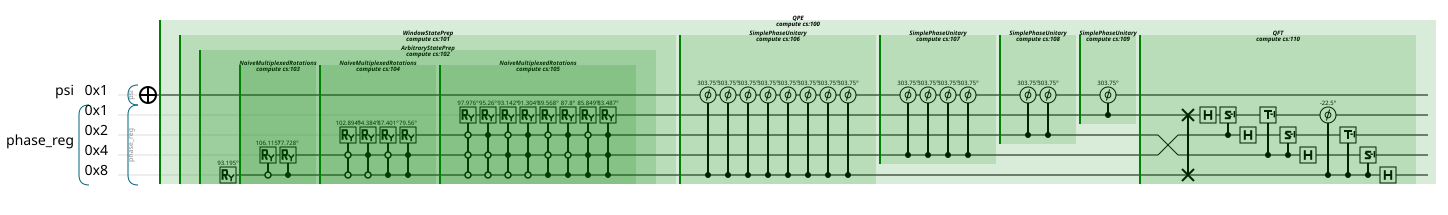

In [6]:
kaiser_state_amps = compute_amplitudes_kaiser_window(n_qubits=bits_of_precision, alpha=0.5)
kaiser_window = WindowStatePrep(amps=kaiser_state_amps.tolist())
kaiser_window_prob = run_qpe_with_window(kaiser_window, True)

Success probability (Kaiser window)     : 0.9126455891437215


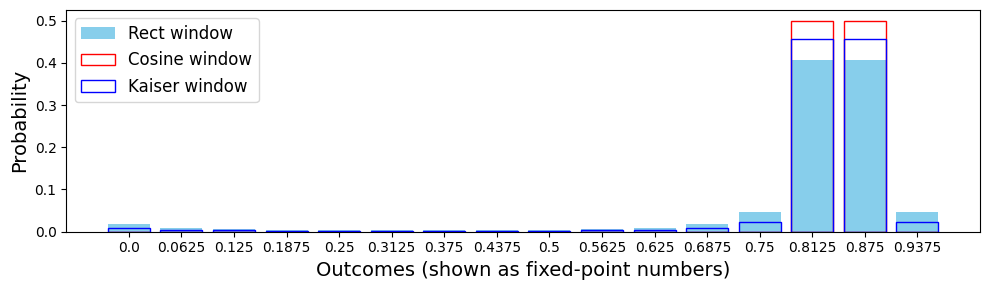

In [7]:
succ_prob_kaiser = np.sum(kaiser_window_prob[0.8125] + kaiser_window_prob[0.875])
print(f"Success probability (Kaiser window)     : {succ_prob_kaiser}")

plot_success_prob(rect_window_prob.keys(), rect_window_prob.values(), cosine_window_prob.values(), kaiser_window_prob.values())

You can see that, while the cosine window performs the best, the Kaiser window with its likely suboptimal parameter does fairly well! As expected, the rectangular window performs the worst.

### True phase is exactly representable itself

Now we will test the case in which the true phase is exactly representable with 4 bits of precision, which is a pathological case for the cosine window.

Success probability (rectangular window): 0.999999999999998
Success probability (cosine window)     : 0.8053661634360719
Success probability (Kaiser window)     : 0.9774740328315601


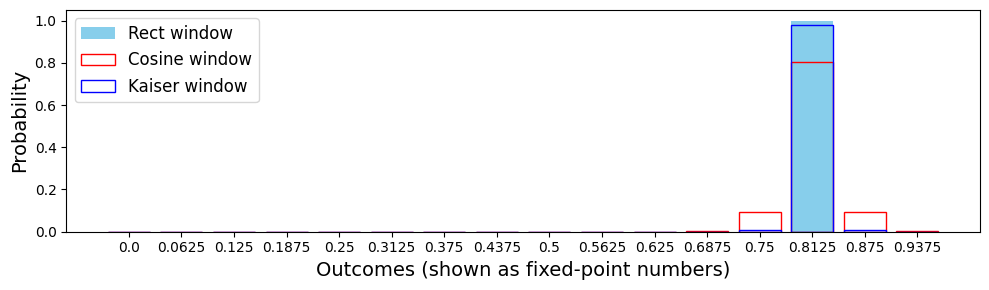

In [8]:
phase = 1/2 + 1/4 + 1/16    # 0.8125

rect_window_prob = run_qpe_with_window(RectWindow())
cosine_window_prob = run_qpe_with_window(CosineWindow())
kaiser_window = WindowStatePrep(amps=kaiser_state_amps.tolist())
kaiser_window_prob = run_qpe_with_window(kaiser_window)

print(f"Success probability (rectangular window): {rect_window_prob[phase]}")
print(f"Success probability (cosine window)     : {cosine_window_prob[phase]}")
print(f"Success probability (Kaiser window)     : {kaiser_window_prob[phase]}")

plot_success_prob(rect_window_prob.keys(), rect_window_prob.values(), cosine_window_prob.values(), kaiser_window_prob.values())

As expected, the cosine window performs the worst, and the rectangular window performs the best. The Kaiser window is again in the middle!

Overall, the Kaiser window is doing fairly well in both extreme cases, which is promising for real world problems where we won't know where the true phase lies.

There is still a lot to explore using window functions. Workbench Algorithms includes some emulators of various window functions. Additionally, if you know the amplitudes of the window functions, you could use the state preparation routines in Workbench Algorithms to come up with the circuit that prepares the window state (which we leveraged for simulating the Kaiser window)!

Finally, Workbench Algorithms also allows you to _emulate_ the window functions using the [`WindowEmulator`](https://construct.psiquantum.com/docs/psiqdk-algorithms/autoapi/psiqdk/algorithms/index.html#psiqdk.algorithms.WindowEmulator) `Qubrick`, although this should really only be used for debugging purposes.

## Summary

In this tutorial, we explored the window functions that can be applied to the phase register before applying the core QPE algorithm.

* The default QPE algorithm relies on rectangular window function. It works well if the true phase is exactly representable with the given precision, but introduces "signal leakage", returning values far from the true phase, if the true phase is halfway between two representable values.
* The cosine window function behaves in the opposite way: it works well if the true phase is halfway between two representable values but not if it is exactly representable itself.
* The Kaiser window function is the middle ground: it lands somewhere between the other two windows, doing reasonably well for both scenarios.